FITTING GARCH(1,1) (training data only)
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -78082.4
Distribution:                  Normal   AIC:                           156173.
Method:            Maximum Likelihood   BIC:                           156203.
                                        No. Observations:                15602
Date:                Mon, Apr 27 2026   Df Residuals:                    15601
Time:                        12:10:45   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             1.0093      0.1

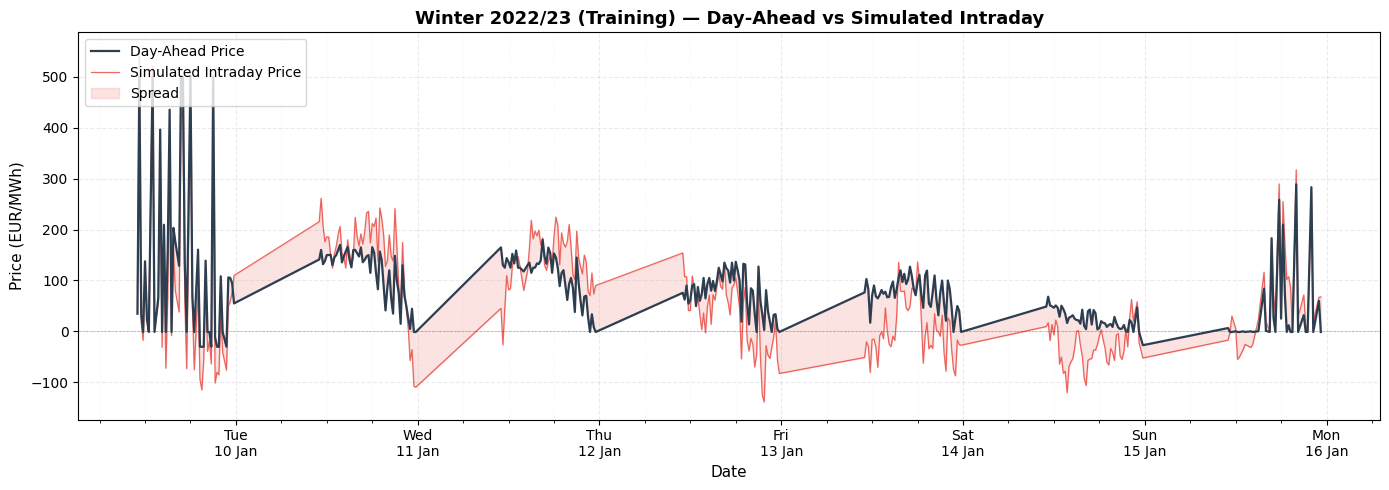

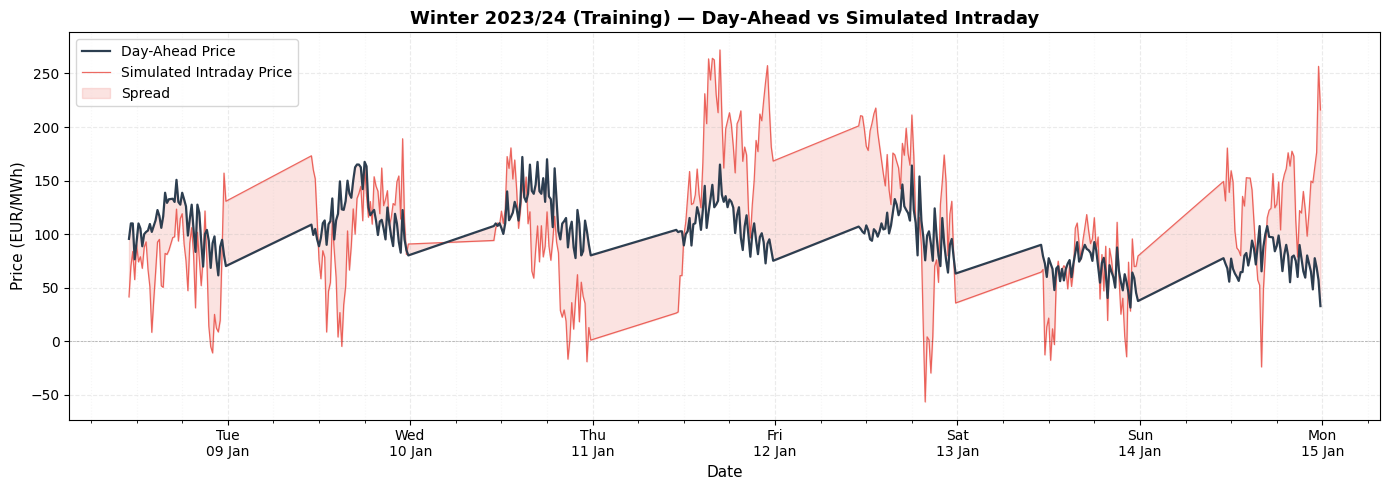

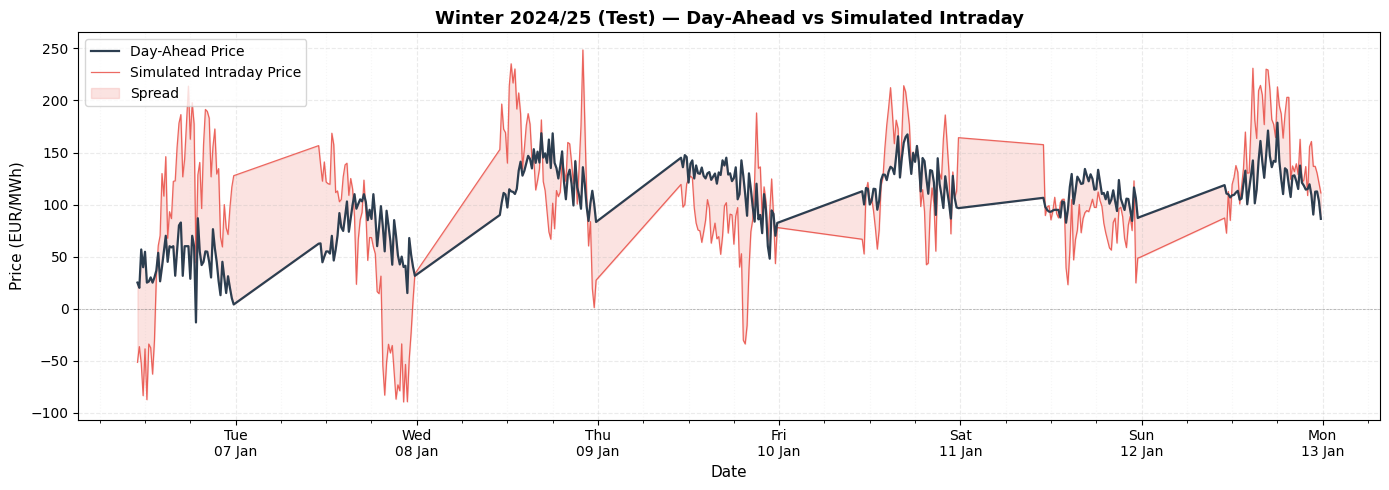

NORMALISATION PARAMETERS (from training data)
  price_eur_mwh         mu=126.860  std=100.424
  p_intraday            mu=126.992  std=115.683
  epsilon               mu=0.132  std=60.275
  sigma                 mu=26.415  std=4.987
  wind_total_mw         mu=5192.576  std=3109.844
  load_mw               mu=14391.238  std=2013.362

FINAL STATE DATASET
  Total rows:      23423
  Training rows:   15602
  Test rows:       7821
  State features:  ['price_da_norm', 'price_id_norm', 'spread_norm', 'sigma_norm', 'wind_norm', 'load_norm', 'ttd_norm']

  Missing values:
timestamp        0
season           0
price_da_norm    0
price_id_norm    0
spread_norm      0
sigma_norm       0
wind_norm        0
load_norm        0
ttd_norm         0
price_eur_mwh    0
p_intraday       0
epsilon          0
sigma            0
dtype: int64

  TTD values present: [np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]

  sigma stats by season:
          count    mean    std     min     25%     5

In [ ]:
#The purpose of this code was to investigate and eventually model intraday markets using GARCH(1,1) volatility
!pip install arch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from arch import arch_model

# ─────────────────────────────────────────────
# 1. Load data
# ─────────────────────────────────────────────

da = pd.read_csv("/content/drive/MyDrive/MEng Project/datasdayahead_prices.csv", parse_dates=["timestamp"])
sm = pd.read_csv("/content/drive/MyDrive/MEng Project/datassmard_fundamentals.csv", parse_dates=["timestamp"])

da = da.drop(columns=["market"], errors="ignore")
sm = sm.drop(columns=["wind_offshore_mw"], errors="ignore")

df = da.merge(
    sm[["timestamp", "wind_total_mw", "load_mw"]],
    on="timestamp", how="inner"
).sort_values("timestamp").reset_index(drop=True)

# ─────────────────────────────────────────────
# 2. Compute log returns
# Standard input for GARCH — compresses
# extreme price spikes from 2022/23 crisis
# ─────────────────────────────────────────────

df["log_return"] = np.log(
    df["price_eur_mwh"].clip(lower=1) /
    df["price_eur_mwh"].shift(1).clip(lower=1)
) * 100

df = df.dropna(subset=["log_return"]).reset_index(drop=True)

# ─────────────────────────────────────────────
# 3. Fit GARCH(1,1) on training data only
# sigma^2(t) = omega + alpha*eps^2(t-1) + beta*sigma^2(t-1)
# Wind and load are not in the variance equation
# ─────────────────────────────────────────────

train_mask = df["season"].isin(["2022/23", "2023/24"])
train      = df[train_mask].copy()

print("=" * 55)
print("FITTING GARCH(1,1) (training data only)")
print("=" * 55)

garch = arch_model(
    train["log_return"],
    vol="Garch",
    p=1,
    q=1,
    dist="normal",
    rescale=False,
)

garch_result = garch.fit(disp="off", options={"maxiter": 500})
print(garch_result.summary())

params = garch_result.params
omega  = params["omega"]
alpha  = params["alpha[1]"]
beta   = params["beta[1]"]
print(f"\n  alpha + beta = {alpha + beta:.4f} (must be < 1 for stationarity)")

# ─────────────────────────────────────────────
# 4. Compute conditional volatility for all data
# Recursively apply frozen training parameters
# to the full series including test set
# ─────────────────────────────────────────────

SIGMA_FLOOR = 0.5
SIGMA_CAP   = 30.0

def compute_garch_vol(log_returns, omega, alpha, beta, sigma2_init):
    """
    Recursively compute GARCH(1,1) conditional std dev
    using frozen parameters from training fit.
    sigma^2(t) = omega + alpha*eps^2(t-1) + beta*sigma^2(t-1)
    """
    n         = len(log_returns)
    sigma2    = np.zeros(n)
    sigma2[0] = sigma2_init

    for t in range(1, n):
        sigma2[t] = (omega
                     + alpha * log_returns.iloc[t-1] ** 2
                     + beta  * sigma2[t-1])
        sigma2[t] = max(sigma2[t], 1e-6)

    return np.sqrt(sigma2)

sigma2_init = df.loc[0, "log_return"] ** 2

full_vol = compute_garch_vol(
    df["log_return"],
    omega, alpha, beta,
    sigma2_init
)

mean_price  = df.loc[train_mask, "price_eur_mwh"].mean()
df["sigma"] = (full_vol * mean_price / 100).clip(SIGMA_FLOOR, SIGMA_CAP)

print(f"\nsigma(t) stats after GARCH(1,1):")
print(df.groupby("season")["sigma"].describe().round(3))
print()

# ─────────────────────────────────────────────
# 5. Simulate OU spread — baseline theta=0.1
# e(t+1) = e(t) + theta*(0 - e(t)) + sigma(t)*N(0,1)
# ─────────────────────────────────────────────

np.random.seed(42)

def simulate_ou(sigma_series, theta):
    n       = len(sigma_series)
    epsilon = np.zeros(n)
    for t in range(1, n):
        epsilon[t] = (
            epsilon[t-1]
            + theta * (0 - epsilon[t-1])
            + sigma_series[t] * np.random.normal()
        )
    return epsilon

df["epsilon"]    = simulate_ou(df["sigma"].values, theta=0.1)
df["p_intraday"] = df["price_eur_mwh"] + df["epsilon"]

print("Spread stats:")
print(df.groupby("season")["epsilon"].describe().round(3))
print()

# ─────────────────────────────────────────────
# 6. Plot — one week per season, display only
# ─────────────────────────────────────────────

WEEKS = {
    "2022/23": ("2023-01-09", "2023-01-16"),
    "2023/24": ("2024-01-08", "2024-01-15"),
    "2024/25": ("2025-01-06", "2025-01-13"),
}

SEASON_LABELS = {
    "2022/23": "2022/23 (Training)",
    "2023/24": "2023/24 (Training)",
    "2024/25": "2024/25 (Test)",
}

for season, (w_start, w_end) in WEEKS.items():
    subset = df[
        (df["season"] == season) &
        (df["timestamp"] >= w_start) &
        (df["timestamp"] <  w_end)
    ]

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(subset["timestamp"], subset["price_eur_mwh"],
            color="#2C3E50", linewidth=1.6, label="Day-Ahead Price", zorder=3)
    ax.plot(subset["timestamp"], subset["p_intraday"],
            color="#E8453C", linewidth=0.9, alpha=0.8,
            label="Simulated Intraday Price", zorder=2)

    ax.fill_between(subset["timestamp"],
                    subset["price_eur_mwh"], subset["p_intraday"],
                    alpha=0.15, color="#E8453C", label="Spread")

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.3)

    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d %b"))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))

    ax.grid(True, which="major", alpha=0.25, linestyle="--")
    ax.grid(True, which="minor", alpha=0.1, linestyle=":")

    ax.set_ylabel("Price (EUR/MWh)", fontsize=11)
    ax.set_xlabel("Date", fontsize=11)

    ax.legend(fontsize=10, loc="upper left")
    ax.set_title(
        f"Winter {SEASON_LABELS[season]} — Day-Ahead vs Simulated Intraday",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────
# 7. Prepare full state dataset for PPO training
# ─────────────────────────────────────────────

df["ttd_min"]  = 60 - df["timestamp"].dt.minute
df["ttd_norm"] = df["ttd_min"] / 60.0

def normalise(col, df, mask):
    mu  = df.loc[mask, col].mean()
    std = df.loc[mask, col].std()
    return (df[col] - mu) / std, mu, std

df["price_da_norm"], mu_da, std_da   = normalise("price_eur_mwh", df, train_mask)
df["price_id_norm"], mu_id, std_id   = normalise("p_intraday", df, train_mask)
df["spread_norm"],   mu_sp, std_sp   = normalise("epsilon", df, train_mask)
df["sigma_norm"],    mu_sig, std_sig = normalise("sigma", df, train_mask)
df["wind_norm"],     mu_wind, std_wind = normalise("wind_total_mw", df, train_mask)
df["load_norm"],     mu_load, std_load = normalise("load_mw", df, train_mask)

print("=" * 55)
print("NORMALISATION PARAMETERS (from training data)")
print("=" * 55)

for col, mu, std in [
    ("price_eur_mwh", mu_da, std_da),
    ("p_intraday", mu_id, std_id),
    ("epsilon", mu_sp, std_sp),
    ("sigma", mu_sig, std_sig),
    ("wind_total_mw", mu_wind, std_wind),
    ("load_mw", mu_load, std_load),
]:
    print(f"  {col:20s}  mu={mu:.3f}  std={std:.3f}")

print()

STATE_COLS = [
    "timestamp",
    "season",
    "price_da_norm",
    "price_id_norm",
    "spread_norm",
    "sigma_norm",
    "wind_norm",
    "load_norm",
    "ttd_norm",
    "price_eur_mwh",
    "p_intraday",
    "epsilon",
    "sigma",
]

state_df = df[STATE_COLS].copy()

train_df = state_df[state_df["season"].isin(["2022/23", "2023/24"])].reset_index(drop=True)
test_df  = state_df[state_df["season"] == "2024/25"].reset_index(drop=True)

print("=" * 55)
print("FINAL STATE DATASET")
print("=" * 55)

print(f"  Total rows:      {len(state_df)}")
print(f"  Training rows:   {len(train_df)}")
print(f"  Test rows:       {len(test_df)}")

print(
    f"  State features:  {[c for c in STATE_COLS if c not in ['timestamp','season','price_eur_mwh','p_intraday','epsilon','sigma']]}"
)

print(f"\n  Missing values:\n{state_df.isnull().sum()}")
print(f"\n  TTD values present: {sorted(state_df['ttd_norm'].unique())}")

print(f"\n  sigma stats by season:")
print(df.groupby("season")["sigma"].describe().round(3))

print("\n  Training sample:")
print(train_df.head(8).to_string(index=False))

assert test_df["season"].unique().tolist() == ["2024/25"], "Test set contaminated"
assert not train_df["season"].isin(["2024/25"]).any(), "Training set contaminated"

print("\n  Data leakage check: PASSED")
print("\nState dataset ready for PPO environment.")